Lanette Tyler   
Homework 9   
ST558   
Spring 2026

# Introduction

## Purpose
The purpose of this homework assignment is to fit three different classes of supervised learning models to a student-selected dataset, choose the best fit for each class, and then choose an overall best model.

## Data
The selected dataset is [Maternal Health Risk](https://archive-beta.ics.uci.edu/dataset/863/maternal+health+risk) available at the UCI Machine Learning Repository.

This dataset was collected from different hospitals, community clinics, and maternity health care centers from rural areas of Bangladesh through an Internet of Things-based risk monitoring system. The data contains measurements of significant risk factors for maternal mortality as numeric predictor variables, along with a categorical response variable of risk rating (low, mid, or high). The measurements recorded are for age, systolic blood pressure, diastolic blood pressure, blood sugar, body temperature, and heart rate. The data set contains 1014 observations of 7 variables.

The goal of the modeling is to understand and predict the relationship between these heatlh factors and pregnancy risk level. The response variable derived from the data to be considered here is binary (high risk or not), and logistic regression, classification tree, and random forest models will be fit. 

# Preliminary Steps
*  Import Modules
*  Create Spark Session
*  Read in Data
*  Convert Data to Spark SQL Data Frame

In [112]:
#import modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [113]:
#start spark session
from pyspark.sql import SparkSession
spark = SparkSession.builder.getOrCreate()

In [114]:
#read in data as pandas data frame
mom_data = pd.read_csv(
    "https://cdn.uci-ics-mlr-prod.aws.uci.edu/863/maternal%2Bhealth%2Brisk/"
    "Maternal+Health%20Risk%20Data%20Set.csv")
mom_data.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


In [115]:
#convert to Spark SQL data frame
momData = spark.createDataFrame(mom_data)
momData.show(10)

+---+----------+-----------+----+--------+---------+---------+
|Age|SystolicBP|DiastolicBP|  BS|BodyTemp|HeartRate|RiskLevel|
+---+----------+-----------+----+--------+---------+---------+
| 25|       130|         80|15.0|    98.0|       86|high risk|
| 35|       140|         90|13.0|    98.0|       70|high risk|
| 29|        90|         70| 8.0|   100.0|       80|high risk|
| 30|       140|         85| 7.0|    98.0|       70|high risk|
| 35|       120|         60| 6.1|    98.0|       76| low risk|
| 23|       140|         80|7.01|    98.0|       70|high risk|
| 23|       130|         70|7.01|    98.0|       78| mid risk|
| 35|        85|         60|11.0|   102.0|       86|high risk|
| 32|       120|         90| 6.9|    98.0|       70| mid risk|
| 42|       130|         80|18.0|    98.0|       70|high risk|
+---+----------+-----------+----+--------+---------+---------+
only showing top 10 rows


# Data Splitting, Metrics, and Models

## Splitting the Data into Training and Test Sets

In [116]:
#split the data, view train and test counts, view train and test sets
train, test = momData.randomSplit([0.8, 0.2], seed = 12)
print("Train Count: ", train.count())
print("Test Count: ", test.count(), "\n")
print("Training Set:")
print(train.show(5))
print("\nTest Set:")
print(test.show(5))

Train Count:  814
Test Count:  200 

Training Set:
+---+----------+-----------+----+--------+---------+---------+
|Age|SystolicBP|DiastolicBP|  BS|BodyTemp|HeartRate|RiskLevel|
+---+----------+-----------+----+--------+---------+---------+
| 23|       130|         70|7.01|    98.0|       78| mid risk|
| 25|       130|         80|15.0|    98.0|       86|high risk|
| 29|        90|         70| 8.0|   100.0|       80|high risk|
| 30|       140|         85| 7.0|    98.0|       70|high risk|
| 35|       120|         60| 6.1|    98.0|       76| low risk|
+---+----------+-----------+----+--------+---------+---------+
only showing top 5 rows
None

Test Set:
+---+----------+-----------+----+--------+---------+---------+
|Age|SystolicBP|DiastolicBP|  BS|BodyTemp|HeartRate|RiskLevel|
+---+----------+-----------+----+--------+---------+---------+
| 23|       140|         80|7.01|    98.0|       70|high risk|
| 20|       120|         75|7.01|   100.0|       70| mid risk|
| 35|        85|         60

## Metrics
Both the loss function for fitting the models and the model metric for determining the quality of predictions for the best fit models for each class and thus selecting the overall best model will be log loss. The log loss is usually a better metric for logistic regression since it considers more information than simple accuracy. The log loss considers the model's probability that a classifcation will be what is predicted, and not just whether it is predicted accurately. 

## Models
The data set will be transformed to contain a binary response variable for whether the pregnancies/births are high risk or not. Three appropriate models for binary classification with numeric predictors will be fit: Logistic Regression, Classification Tree, and Random Forest Models.

### Logistic Regression, with Penalization
Logistic regression models are used to predict binary response variables such as 0/1, true/false, and success/failure. Both numeric and categorical predictors are appropriate for this model. The model produces a probability that a given combination of predictors will result in success. Probability of success is modeled with the logistic function, which is sigmoid and near linear between zero and one, the region in question. Predictions are between zero and one, with success predicted for probabilities greater than 0.5. Model parameters are betas (intercept and coefficents) and penalty factors. Like linear regression models, logistic regression models can be penalized using LASSO, Ridge, or Elastic Net regression.

### Classification Tree
A classification tree is a pragmatic, non-linear model that divides the predictor space into regions and assigns the most common classification for that region of data as the predicted classification for sets of predictors in that region. Both numerical and categorical predictors work with this model.

### Random Forest
A random forerst is a type of ensemble tree model. Ensemble trees are tree models built from the average of many trees. Bagging, random forests, and boosted trees are all ensemble trees. A random forest model is a special case of bagging. A bagging model is the average of a multitude of trees built from bootstep aggregation (bagging), or re-sampling from the dataset with replacement to develop additional, possibly repeated, datasets. Random forests differ from bagging in that at each node a random number of predictors is selected for consideration, rather than all of them every time. This prevents a dominant predictor from overwhelming the model. Both numeric and categorical predictors are acceptable.

# Fit Logistic Regression Model

## Set Up Data Transformations to Use in Pipeline
*  Create Dummy Variable and Make it Binary
*  Consider Log Transformations
*  Log Transform Selected Predictors
*  Rename Response Variable as "label"
*  Put Predictor Variables into One Column as "features"

In [117]:
#import functions for transformations
from pyspark.ml.feature import StringIndexer, Binarizer, SQLTransformer, VectorAssembler

### Create Dummy Variable and Make it Binary

In [118]:
#create dummy variable from response variable RiskLevel
indexer = StringIndexer(inputCols = ["RiskLevel"], outputCols = ["RiskLevel_num"])
indexerTrans = indexer.fit(train)
indexerTrans.transform(train).show(10)

+---+----------+-----------+----+--------+---------+---------+-------------+
|Age|SystolicBP|DiastolicBP|  BS|BodyTemp|HeartRate|RiskLevel|RiskLevel_num|
+---+----------+-----------+----+--------+---------+---------+-------------+
| 23|       130|         70|7.01|    98.0|       78| mid risk|          1.0|
| 25|       130|         80|15.0|    98.0|       86|high risk|          2.0|
| 29|        90|         70| 8.0|   100.0|       80|high risk|          2.0|
| 30|       140|         85| 7.0|    98.0|       70|high risk|          2.0|
| 35|       120|         60| 6.1|    98.0|       76| low risk|          0.0|
| 35|       140|         90|13.0|    98.0|       70|high risk|          2.0|
| 19|       120|         80| 7.0|    98.0|       70| mid risk|          1.0|
| 23|        90|         60|7.01|    98.0|       76| low risk|          0.0|
| 25|       110|         89|7.01|    98.0|       77| low risk|          0.0|
| 32|       120|         90| 6.9|    98.0|       70| mid risk|          1.0|

In [119]:
#make dummy variable RiskLevel_num binary
binaryTrans = Binarizer(threshold = 1.5, inputCols = ["RiskLevel_num"], 
                        outputCols = ["HighRisk"])
binaryTrans.transform(indexerTrans.transform(train)).show(10)

+---+----------+-----------+----+--------+---------+---------+-------------+--------+
|Age|SystolicBP|DiastolicBP|  BS|BodyTemp|HeartRate|RiskLevel|RiskLevel_num|HighRisk|
+---+----------+-----------+----+--------+---------+---------+-------------+--------+
| 23|       130|         70|7.01|    98.0|       78| mid risk|          1.0|     0.0|
| 25|       130|         80|15.0|    98.0|       86|high risk|          2.0|     1.0|
| 29|        90|         70| 8.0|   100.0|       80|high risk|          2.0|     1.0|
| 30|       140|         85| 7.0|    98.0|       70|high risk|          2.0|     1.0|
| 35|       120|         60| 6.1|    98.0|       76| low risk|          0.0|     0.0|
| 35|       140|         90|13.0|    98.0|       70|high risk|          2.0|     1.0|
| 19|       120|         80| 7.0|    98.0|       70| mid risk|          1.0|     0.0|
| 23|        90|         60|7.01|    98.0|       76| low risk|          0.0|     0.0|
| 25|       110|         89|7.01|    98.0|       77| l

### Consider Log Transformations

Text(0.5, 1.0, 'Heart Rate')

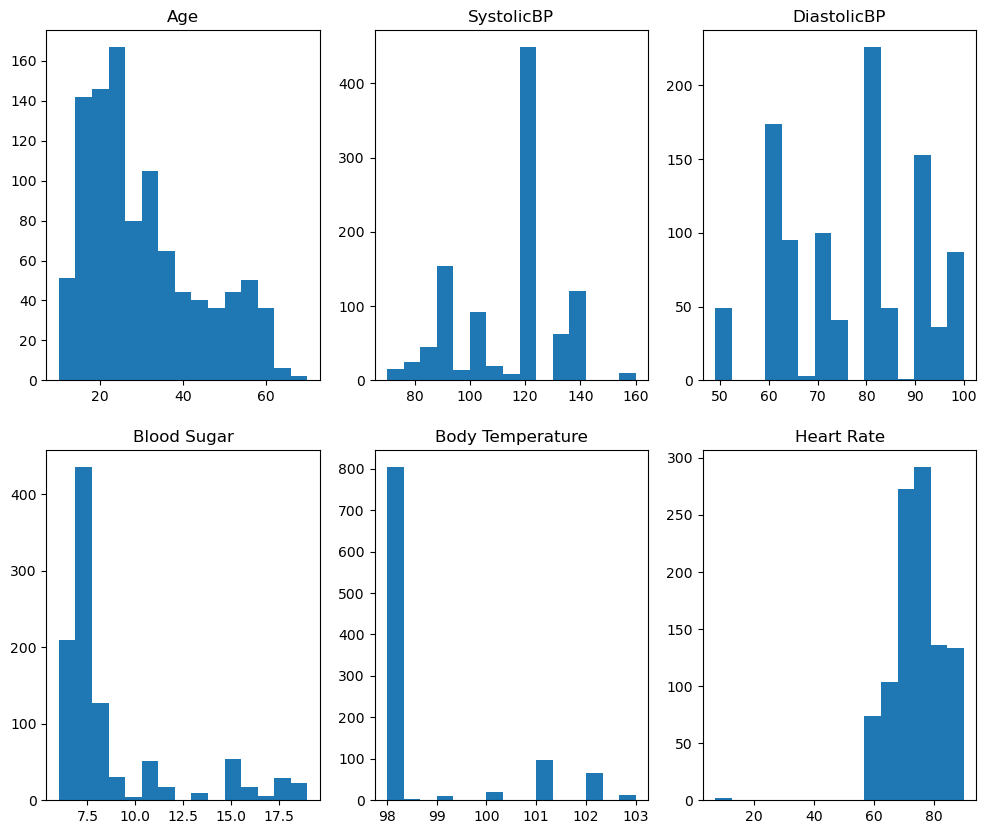

In [120]:
#make histograms of numeric predictors to visualize distributions
#variables to consider log transformations
#use original pandas data frame mom_data to use pandas functions for histograms
fig, axes = plt.subplots(nrows = 2, ncols = 3, figsize = (12, 10))

axes[0, 0].hist(mom_data["Age"], bins = 15)
axes[0, 0].set_title('Age')

axes[0, 1].hist(mom_data["SystolicBP"], bins = 15)
axes[0, 1].set_title('SystolicBP')

axes[0, 2].hist(mom_data["DiastolicBP"], bins = 15)
axes[0, 2].set_title('DiastolicBP')

axes[1, 0].hist(mom_data["BS"], bins = 15)
axes[1, 0].set_title('Blood Sugar')
                      
axes[1, 1].hist(mom_data["BodyTemp"], bins = 15)
axes[1, 1].set_title('Body Temperature')

axes[1, 2].hist(mom_data["HeartRate"], bins = 15)
axes[1, 2].set_title('Heart Rate')

The distributions of age, blood sugar, and body temperature are right-skewed and log transformation will be considered for them. The distribution of the remaining numeric predictors systolic blood pressure, diastolic blood pressure, and heart rate are not right-skewed, and seem somewhat normal. They will not be log transformed.

Text(0.5, 1.0, 'Heart Rate')

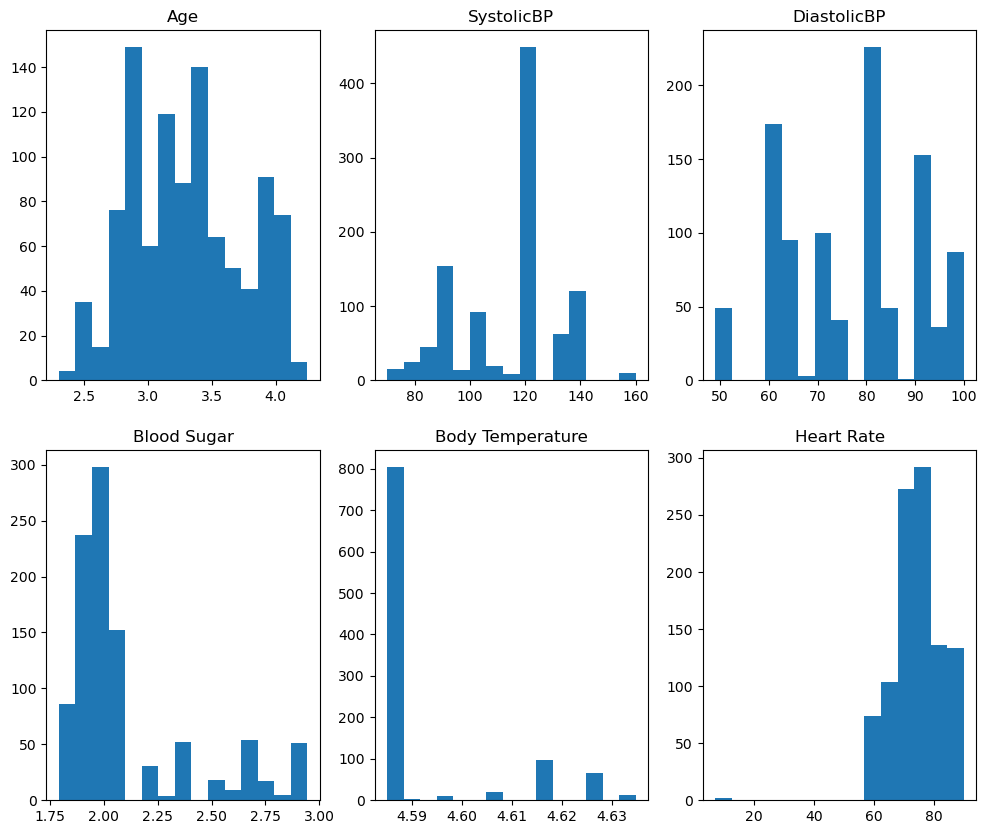

In [121]:
#make histograms of numeric predictor variables to consider log 
#transformations make histograms of log transformed data for age, blood sugar, 
#and body temperature 
#use original pandas data frame mom_data to use pandas functions for histograms

fig, axes = plt.subplots(nrows = 2, ncols = 3, figsize = (12, 10))

axes[0, 0].hist(np.log(mom_data["Age"]), bins = 15)
axes[0, 0].set_title('Age')

axes[0, 1].hist(mom_data["SystolicBP"], bins = 15)
axes[0, 1].set_title('SystolicBP')

axes[0, 2].hist(mom_data["DiastolicBP"], bins = 15)
axes[0, 2].set_title('DiastolicBP')

axes[1, 0].hist(np.log(mom_data["BS"]), bins = 15)
axes[1, 0].set_title('Blood Sugar')
                      
axes[1, 1].hist(np.log(mom_data["BodyTemp"]), bins = 15)
axes[1, 1].set_title('Body Temperature')

axes[1, 2].hist(mom_data["HeartRate"], bins = 15)
axes[1, 2].set_title('Heart Rate')

The distributions for Blood Sugar and Body Temperature are still similarly right-skewed with log transformations, so they will not be log transformed. The Age distribution looks much closer to normal, so Age will be log transformed.

### Finalize General Dataset for Logistic Regression Modeling
The dataset is not standardized here, and will be used as is for classes of models that do not require it. It will be standardized for the class of models that does require it.

In [122]:
#select needed variables (all predictors and binary response), 
#take logs of selected variables, and rename response as "label"
sqlTrans = SQLTransformer(
    statement = """
                SELECT log(Age) as log_age, SystolicBP, DiastolicBP, BS, 
                       BodyTemp, HeartRate, HighRisk as label
                FROM __THIS__
                """
)
sqlTrans.transform(
    binaryTrans.transform(
        indexerTrans.transform(train)
    )
).show(10)

+------------------+----------+-----------+----+--------+---------+-----+
|           log_age|SystolicBP|DiastolicBP|  BS|BodyTemp|HeartRate|label|
+------------------+----------+-----------+----+--------+---------+-----+
|3.1354942159291497|       130|         70|7.01|    98.0|       78|  0.0|
|3.2188758248682006|       130|         80|15.0|    98.0|       86|  1.0|
| 3.367295829986474|        90|         70| 8.0|   100.0|       80|  1.0|
|3.4011973816621555|       140|         85| 7.0|    98.0|       70|  1.0|
|3.5553480614894135|       120|         60| 6.1|    98.0|       76|  0.0|
|3.5553480614894135|       140|         90|13.0|    98.0|       70|  1.0|
|2.9444389791664403|       120|         80| 7.0|    98.0|       70|  0.0|
|3.1354942159291497|        90|         60|7.01|    98.0|       76|  0.0|
|3.2188758248682006|       110|         89|7.01|    98.0|       77|  0.0|
|3.4657359027997265|       120|         90| 6.9|    98.0|       70|  0.0|
+------------------+----------+-------

In [123]:
#assemble predictor variables into features column for modeling
assembler = VectorAssembler(inputCols = ["log_age", "SystolicBP", 
                                         "DiastolicBP", "BS", "BodyTemp", "HeartRate"],
                            outputCol = "features", handleInvalid = "keep")
assembler.transform(
    sqlTrans.transform(
        binaryTrans.transform(
            indexerTrans.transform(train)
        )
    )
).show(10)

+------------------+----------+-----------+----+--------+---------+-----+--------------------+
|           log_age|SystolicBP|DiastolicBP|  BS|BodyTemp|HeartRate|label|            features|
+------------------+----------+-----------+----+--------+---------+-----+--------------------+
|3.1354942159291497|       130|         70|7.01|    98.0|       78|  0.0|[3.13549421592914...|
|3.2188758248682006|       130|         80|15.0|    98.0|       86|  1.0|[3.21887582486820...|
| 3.367295829986474|        90|         70| 8.0|   100.0|       80|  1.0|[3.36729582998647...|
|3.4011973816621555|       140|         85| 7.0|    98.0|       70|  1.0|[3.40119738166215...|
|3.5553480614894135|       120|         60| 6.1|    98.0|       76|  0.0|[3.55534806148941...|
|3.5553480614894135|       140|         90|13.0|    98.0|       70|  1.0|[3.55534806148941...|
|2.9444389791664403|       120|         80| 7.0|    98.0|       70|  0.0|[2.94443897916644...|
|3.1354942159291497|        90|         60|7.01|  

## Make Pipeline, Cross Validate, and Extract Best Model

In [124]:
#import functions
from pyspark.ml import Pipeline
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

In [125]:
#create pipeline
logR = LogisticRegression() #standardization = True is default
paramGrid = ParamGridBuilder() \
    .addGrid(logR.regParam, [0.0, 0.01, 0.04, 0.06, 0.1, 1.0]) \
    .addGrid(logR.elasticNetParam, [0.0, 0.5, 0.8, 0.9, 1.0]) \
    .build()
pipeline = Pipeline(stages = [indexerTrans, binaryTrans, sqlTrans, assembler, logR])

In [126]:
#define cross validation
cv = CrossValidator(estimator = pipeline,
                    estimatorParamMaps = paramGrid,
                    evaluator = MulticlassClassificationEvaluator(metricName = 'logLoss'),
                    numFolds = 5)

In [127]:
#fit model
logR_Model = cv.fit(train)
logR_Model

CrossValidatorModel_cf50424c608d

In [128]:
#see model fits
my_list = []
for i in range(len(paramGrid)):
    my_list.append([logR_Model.avgMetrics[i], paramGrid[i].values()])
print("average log loss, [regParam, elasticNetParam]")
my_list

average log loss, [regParam, elasticNetParam]


[[0.336729910358191, dict_values([0.0, 0.0])],
 [0.33672991035818994, dict_values([0.0, 0.5])],
 [0.3367299103581914, dict_values([0.0, 0.8])],
 [0.3367299103581887, dict_values([0.0, 0.9])],
 [0.3367299103581879, dict_values([0.0, 1.0])],
 [0.33607362660409906, dict_values([0.01, 0.0])],
 [0.3359576111381808, dict_values([0.01, 0.5])],
 [0.33645006531344135, dict_values([0.01, 0.8])],
 [0.33666961412941576, dict_values([0.01, 0.9])],
 [0.33691124865933175, dict_values([0.01, 1.0])],
 [0.34607242445240544, dict_values([0.04, 0.0])],
 [0.35156002750655824, dict_values([0.04, 0.5])],
 [0.35837192423535974, dict_values([0.04, 0.8])],
 [0.3613999764030905, dict_values([0.04, 0.9])],
 [0.36431150861016837, dict_values([0.04, 1.0])],
 [0.35372754205598855, dict_values([0.06, 0.0])],
 [0.3658137321689575, dict_values([0.06, 0.5])],
 [0.37877862677565066, dict_values([0.06, 0.8])],
 [0.383338190356047, dict_values([0.06, 0.9])],
 [0.3885029416572676, dict_values([0.06, 1.0])],
 [0.367853165955

In [129]:
#extract tuning parameters for best fit, which are stored in logR_Model
comp = my_list[0][0]
for i in my_list:
    if i[0] < comp:
        comp = i[0]
        current_min = i
print([current_min])

[[0.3359576111381808, dict_values([0.01, 0.5])]]


The best fit logistic regression model with lowest average log loss of 0.3360 has regParam = 0.01 and elasticNetParam = 0.5. The regParam is small, meaning that the penalty applied to the coefficients is low. ElasticNetParam is 0.5, meaning that this model is an equal mix of ridge regression and LASSO regression.

In [130]:
#view intercept and coefficients
print("Best Fit Logistic Regression Model Intercept: ",
      logR_Model.bestModel.stages[-1].intercept)
print("\nBest Fit Logistic Regression Model Coefficients:")
list(zip(train.columns[0:6], 
    logR_Model.bestModel.stages[-1].coefficients))

Best Fit Logistic Regression Model Intercept:  -62.281634341349985

Best Fit Logistic Regression Model Coefficients:


[('Age', 0.0),
 ('SystolicBP', 0.02267847546497755),
 ('DiastolicBP', 0.038247758192973845),
 ('BS', 0.4022607715653979),
 ('BodyTemp', 0.4986624122730203),
 ('HeartRate', 0.036099976574578314)]

The magnitudes of the coefficients for blood sugar and body temperature are an order of magnitude larger than the magnitudes of the coefficients for systolic blood pressure, diastolic blood pressure, and heart rate. These two seem more important for determination of high risk level. The coefficient for age is shrunk to zero, demonstrating LASSO's variable selection capability.

In [131]:
#make predictions on test set with model
logR_preds = logR_Model.transform(test)
logR_preds.show(10)

+------------------+----------+-----------+----+--------+---------+-----+--------------------+--------------------+--------------------+----------+
|           log_age|SystolicBP|DiastolicBP|  BS|BodyTemp|HeartRate|label|            features|       rawPrediction|         probability|prediction|
+------------------+----------+-----------+----+--------+---------+-----+--------------------+--------------------+--------------------+----------+
|3.1354942159291497|       140|         80|7.01|    98.0|       70|  1.0|[3.13549421592914...|[1.83106434916530...|[0.86188847228288...|       0.0|
| 2.995732273553991|       120|         75|7.01|   100.0|       70|  0.0|[2.99573227355399...|[1.47854782488369...|[0.81435313802989...|       0.0|
|3.5553480614894135|        85|         60|11.0|   102.0|       86|  1.0|[3.55534806148941...|[-0.3339340892327...|[0.41728370767075...|       1.0|
|3.4011973816621555|       120|         80| 6.9|   101.0|       76|  0.0|[3.40119738166215...|[0.61629544707052.

In [132]:
logR_error = MulticlassClassificationEvaluator(metricName = 'logLoss') \
    .evaluate(logR_Model.transform(test))
print(logR_error)

0.36522847330440056


# Fit Classification Tree Model
Since the data for the penalized logistic regression model above was standardized as part of the logistic regression function and not as part of the data transformation, the same data transformations will be used to prepare the data for the classification tree.

In [133]:
#import function
from pyspark.ml.classification import DecisionTreeClassifier

In [134]:
#create pipeline and grid of tuning parameters
classTree = DecisionTreeClassifier()
paramGrid2 = ParamGridBuilder() \
    .addGrid(classTree.maxDepth, range(2, 11)) \
    .build()
pipeline2 = Pipeline(stages = [indexerTrans, binaryTrans, sqlTrans, assembler, classTree])

In [135]:
#define cross validation
cv2 = CrossValidator(estimator = pipeline2,
                    estimatorParamMaps = paramGrid2,
                    evaluator = MulticlassClassificationEvaluator(metricName = 'logLoss'),
                    numFolds = 5)

In [136]:
#fit model
classTree_Model = cv2.fit(train)
classTree_Model

CrossValidatorModel_f0df12dfb7e0

In [137]:
#see model fits
my_list2 = []
for i in range(len(paramGrid2)):
    my_list2.append([classTree_Model.avgMetrics[i], paramGrid2[i].values()])
#print("[average log loss, dict_values([regParam, elasticNetParam])]")
my_list2

[[0.3064382783088435, dict_values([2])],
 [0.27217685782294365, dict_values([3])],
 [0.37842958075943567, dict_values([4])],
 [0.525335402926912, dict_values([5])],
 [0.7111468720239423, dict_values([6])],
 [0.7691427139033677, dict_values([7])],
 [1.0929444998073052, dict_values([8])],
 [1.1774338581852488, dict_values([9])],
 [1.256732097670932, dict_values([10])]]

In [138]:
#extract tuning parameter for best fit, which is stored in classTree_Model
comp2 = my_list2[0][0]
for i in my_list2:
    if i[0] < comp2:
        comp2 = i[0]
        current_min2 = i
print([current_min2])

[[0.27217685782294365, dict_values([3])]]


In [ ]:
The best classification tree model fit, the one with the lowest log loss, has a maximum depth of three.

In [139]:
#make predictions on the test set
classTree_preds = classTree_Model.transform(test)
classTree_preds.show(10)

+------------------+----------+-----------+----+--------+---------+-----+--------------------+-------------+--------------------+----------+
|           log_age|SystolicBP|DiastolicBP|  BS|BodyTemp|HeartRate|label|            features|rawPrediction|         probability|prediction|
+------------------+----------+-----------+----+--------+---------+-----+--------------------+-------------+--------------------+----------+
|3.1354942159291497|       140|         80|7.01|    98.0|       70|  1.0|[3.13549421592914...|   [0.0,36.0]|           [0.0,1.0]|       1.0|
| 2.995732273553991|       120|         75|7.01|   100.0|       70|  0.0|[2.99573227355399...| [569.0,41.0]|[0.93278688524590...|       0.0|
|3.5553480614894135|        85|         60|11.0|   102.0|       86|  1.0|[3.55534806148941...| [27.0,136.0]|[0.16564417177914...|       1.0|
|3.4011973816621555|       120|         80| 6.9|   101.0|       76|  0.0|[3.40119738166215...| [569.0,41.0]|[0.93278688524590...|       0.0|
|3.6888794541

Nine of the first ten predictions on the test set by the logistic regression model and by the classificationt ree model are the same.

In [140]:
#evaluate performance on the test set
classTree_error = MulticlassClassificationEvaluator(metricName = 'logLoss') \
    .evaluate(classTree_Model.transform(test))
print(classTree_error)

0.6551175780611962


# Fit Random Forest Model

The same data transformations are used here as were used for the logistic regression model and for the classification tree. These transformations left the data unstandardized. (The logistic regression function standardized the data finternally for that model.)

In [141]:
#import function
from pyspark.ml.classification import RandomForestClassifier

In [142]:
#create pipeline
rForest = RandomForestClassifier(seed = 18)
paramGrid3 = ParamGridBuilder() \
    .addGrid(rForest.maxDepth, [3, 5, 7]) \
    .addGrid(rForest.minInstancesPerNode, [2, 3, 4, 5]) \
    .build()
pipeline3 = Pipeline(stages = [indexerTrans, binaryTrans, sqlTrans, assembler, rForest])

In [143]:
#define cross validation
cv3 = CrossValidator(estimator = pipeline3,
                    estimatorParamMaps = paramGrid3,
                    evaluator = MulticlassClassificationEvaluator(metricName = 'logLoss'),
                    numFolds = 5)

In [144]:
#fit model
rForest_Model = cv3.fit(train)
rForest_Model

CrossValidatorModel_007aeca3c45c

In [145]:
#see model fits
my_list3 = []
for i in range(len(paramGrid3)):
    my_list3.append([rForest_Model.avgMetrics[i], paramGrid3[i].values()])
#print("[average log loss, dict_values([regParam, elasticNetParam])]")
my_list3

[[0.25332936829792607, dict_values([3, 2])],
 [0.2553263141934462, dict_values([3, 3])],
 [0.2548730102779821, dict_values([3, 4])],
 [0.2554284598786025, dict_values([3, 5])],
 [0.21870631354706652, dict_values([5, 2])],
 [0.22033777235705077, dict_values([5, 3])],
 [0.2216337399981818, dict_values([5, 4])],
 [0.22822757647657443, dict_values([5, 5])],
 [0.2029308043181166, dict_values([7, 2])],
 [0.20537937087914887, dict_values([7, 3])],
 [0.20910040554421738, dict_values([7, 4])],
 [0.21637934633339845, dict_values([7, 5])]]

In [146]:
#extract tuning parameters for best fit
comp3 = my_list3[0][0]
for i in my_list3:
    if i[0] < comp3:
        comp3 = i[0]
        current_min3 = i
print([current_min3])

[[0.2029308043181166, dict_values([7, 2])]]


The best fit random forest model has average log loss of 0.2029, with maximum tree depth of seven and minimum instances per node of two.

In [147]:
#make predictions on the test set
rForest_preds = rForest_Model.transform(test)
rForest_preds.show(10)

+------------------+----------+-----------+----+--------+---------+-----+--------------------+--------------------+--------------------+----------+
|           log_age|SystolicBP|DiastolicBP|  BS|BodyTemp|HeartRate|label|            features|       rawPrediction|         probability|prediction|
+------------------+----------+-----------+----+--------+---------+-----+--------------------+--------------------+--------------------+----------+
|3.1354942159291497|       140|         80|7.01|    98.0|       70|  1.0|[3.13549421592914...|[3.24426340801086...|[0.16221317040054...|       1.0|
| 2.995732273553991|       120|         75|7.01|   100.0|       70|  0.0|[2.99573227355399...|[17.2288153181944...|[0.86144076590972...|       0.0|
|3.5553480614894135|        85|         60|11.0|   102.0|       86|  1.0|[3.55534806148941...|[1.00487260410289...|[0.05024363020514...|       1.0|
|3.4011973816621555|       120|         80| 6.9|   101.0|       76|  0.0|[3.40119738166215...|[18.9809215847283.

The random forest model made the same ten predictions on the first ten observations in the test set as the classification tree model did, and varied from the penalized logistic regression by only one prediction. 

In [82]:
#evaluate performance on the test set
rForest_error = MulticlassClassificationEvaluator(metricName = 'logLoss') \
    .evaluate(rForest_Model.transform(test))
print(rForest_error)

0.18489028983479475


# Final Comparison

In [111]:
#Compare performance of best model from each class on the test set
print("Penalized Logistic Regression Model Log Loss: ", logR_error)
print("Classification Tree Model Log Loss: ", classTree_error)
print("Random Forest Model Log Loss: ", rForest_error)

Penalized Logistic Regression Model Log Loss:  0.36522847330440056
Classification Tree Model Log Loss:  0.6551175780611962
Random Forest Model Log Loss:  0.18489028983479475


The random forest model performed best with log loss of 0.1849, followed by the penalized logsitic regression model with log loss of 0.3652. The classification tree model performed worst with log loss of 0.6551. The many trees used to form the random forest model do seem to improve model performance. Since there were only six predictors in the data set, all models were fit with all six predictors.